# Single-Category Model Comparison

This notebook runs a paper-oriented comparison of:

- `SARIMAX`
- `HURDLE`
- `TSB`

using a single aligned product family across the three datasets:

- `M5 / Walmart -> HOUSEHOLD`
- `Favorita -> CLEANING`
- `Amazon -> Health_and_Household`

It is designed to generate actual forecast plots and summary metrics for selected representative products.


## Environment Bootstrap

This cell checks the active notebook kernel and installs missing dependencies into that same Python environment if needed. Run it before the import cells if you see a `ModuleNotFoundError`.


In [1]:
import importlib
import subprocess
import sys

print('Notebook Python:', sys.executable)

required = ['statsmodels']
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f'OK {pkg}')
    except ModuleNotFoundError:
        missing.append(pkg)

if missing:
    print('Installing missing packages in current kernel...', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('Installation complete. Restart the kernel if imports still fail.')
else:
    print('All required packages are available in the current kernel.')


Notebook Python: c:\Users\braya\AppData\Local\Programs\Python\Python311\python.exe
OK statsmodels
All required packages are available in the current kernel.


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(8):
        if (cur / 'src').exists() and (cur / 'reports').exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Repo root:', REPO_ROOT)


Repo root: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main


In [3]:
from src.experiments.run_cross_market_peak_comparison import (
    _load_amazon_selected,
    _load_favorita_selected,
    _load_m5_selected,
)
from src.models.sarimax_model import SARIMAXModel
from src.models.hurdle_model import HurdleModel
from src.models.tsb_model import TSBModel, sbc_classify   # ← sbc_classify is new

# Verify statsforecast is installed
try:
    from statsforecast.models import TSB as _TSB_sf
    print('statsforecast OK — using Nixtla TSB')
except ImportError:
    print('WARNING: statsforecast not found, using pure-Python TSB fallback')
    print('Install with:  pip install statsforecast>=1.7.0')

print('Imports OK')


Install with:  pip install statsforecast>=1.7.0
Imports OK


## Intermittency Analysis Summary

A category scan over the aligned household-oriented family found that the strongest TSB candidates are concentrated in **Amazon Health_and_Household**, not in Favorita CLEANING.

Most intermittent candidate found: `AMAZON_2023 -> B0C1RRLY4Y`

Key diagnostics from the scan:
- `zero_rate ~ 0.953`
- `ADI ~ 21.46`
- `CV2 ~ 0.52`
- very low mean demand

Interpretation:
- this product is far more favorable to `TSB` than the previous weaker examples
- `Favorita/CLEANING` is mostly dense or erratic rather than strongly intermittent
- if the goal is to visibly demonstrate the value of `TSB`, the strongest examples should come from Amazon and possibly a few sparse M5 household SKUs


## Configuration

You can change the selected series here if you want to try other products later.


In [4]:
AMAZON_FILE    = 'Health_and_Household.jsonl'
AMAZON_MAX_ROWS = 100_000
TEST_DAYS       = 365

paper_cases = [
    # ── SARIMAX domain (stable: ADI ≤ 1.32, CV² < 0.49) ─────────────────
    {
        'dataset':          'FAVORITA',
        'series_id':        'item_268443',
        'semantic_product': 'Cleaning product — high demand, stable regime',
        'expected_regime':  'stable',
        'preferred_model':  'SARIMAX',
        'use_weekly_tsb':   False,
    },
    # ── HURDLE domain (erratic: ADI ≤ 1.32, CV² ≥ 0.49) ─────────────────
    {
        'dataset':          'FAVORITA',
        'series_id':        'item_789224',
        'semantic_product': 'Cleaning product — transition / variable regime',
        'expected_regime':  'erratic',
        'preferred_model':  'HURDLE',
        'use_weekly_tsb':   False,
    },
    {
        'dataset':          'M5_WALMART',
        'series_id':        'HOUSEHOLD_1_187_WI_1_validation',
        'semantic_product': 'Household retail — lumpy / transition regime',
        'expected_regime':  'lumpy',
        'preferred_model':  'HURDLE',
        'use_weekly_tsb':   False,
    },
    # ── TSB domain (intermittent: ADI > 1.32, CV² < 0.49) ────────────────
    # These Amazon products have very sparse but low-variance demand —
    # they sell occasionally in consistent small quantities.
    # TSB's probability decay correctly handles the long zero runs.
    # use_weekly_tsb=True aggregates to weekly before fitting TSB,
    # which reduces noise and improves alpha_p calibration.
    {
        'dataset':          'AMAZON_2023',
        'series_id':        'B0BR4W8TBH',
        'semantic_product': 'Personal care — sparse intermittent (TSB domain)',
        'expected_regime':  'intermittent',
        'preferred_model':  'TSB',
        'use_weekly_tsb':   True,
    },
    {
        'dataset':          'AMAZON_2023',
        'series_id':        'B0BZTL57BP',
        'semantic_product': 'Household hygiene — sparse intermittent (TSB domain)',
        'expected_regime':  'intermittent',
        'preferred_model':  'TSB',
        'use_weekly_tsb':   True,
    },
    {
        'dataset':          'AMAZON_2023',
        'series_id':        'B0C1RRLY4Y',
        'semantic_product': 'Household hygiene — weekly intermittent (TSB domain)',
        'expected_regime':  'intermittent',
        'preferred_model':  'TSB',
        'use_weekly_tsb':   True,
    },
]

paper_cases_df = pd.DataFrame(paper_cases)
print(paper_cases_df[['dataset','series_id','expected_regime','preferred_model']].to_string())


       dataset                        series_id expected_regime preferred_model
0     FAVORITA                      item_268443          stable         SARIMAX
1     FAVORITA                      item_789224         erratic          HURDLE
2   M5_WALMART  HOUSEHOLD_1_187_WI_1_validation           lumpy          HURDLE
3  AMAZON_2023                       B0BR4W8TBH    intermittent             TSB
4  AMAZON_2023                       B0BZTL57BP    intermittent             TSB
5  AMAZON_2023                       B0C1RRLY4Y    intermittent             TSB


In [5]:
m5_ids = [c['series_id'] for c in paper_cases if c['dataset'] == 'M5_WALMART']
fav_ids = [c['series_id'] for c in paper_cases if c['dataset'] == 'FAVORITA']
amz_ids = [c['series_id'] for c in paper_cases if c['dataset'] == 'AMAZON_2023']

series_map_by_ds = {
    'M5_WALMART': _load_m5_selected(str(REPO_ROOT / 'data' / 'raw' / 'm5'), m5_ids),
    'FAVORITA': _load_favorita_selected(str(REPO_ROOT / 'data' / 'raw' / 'favorita'), fav_ids, store_nbr=1),
    'AMAZON_2023': _load_amazon_selected(
        str(REPO_ROOT / 'data' / 'raw' / 'amazon_2023' / 'review_categories'),
        AMAZON_FILE,
        amz_ids,
        max_rows=AMAZON_MAX_ROWS,
    ),
}

{k: list(v.keys()) for k, v in series_map_by_ds.items()}


{'M5_WALMART': ['HOUSEHOLD_1_187_WI_1_validation'],
 'FAVORITA': ['item_268443', 'item_789224'],
 'AMAZON_2023': ['B0BR4W8TBH', 'B0BZTL57BP', 'B0C1RRLY4Y']}

In [6]:
# ── SBC Domain Diagnostic ────────────────────────────────────────────────────
# Verify each product is in the expected SBC regime before running models.
# If a TSB case shows tsb_domain=False, replace it with a different product.

print(f"{'Series':<45} {'ADI':>6} {'CV²':>6} {'Regime':<15} {'TSB domain':>10}")
print("-" * 90)

for case in paper_cases:
    ds  = case['dataset']
    sid = case['series_id']
    if sid not in series_map_by_ds.get(ds, {}):
        print(f"  [MISSING] {sid}")
        continue

    y = series_map_by_ds[ds][sid]['sales'].values
    sbc = sbc_classify(y)

    ok = "✓" if case['preferred_model'] == 'TSB' and sbc['tsb_domain'] else (
         "✓" if case['preferred_model'] != 'TSB' and not sbc['tsb_domain'] else
         "✗ MISMATCH")

    print(
        f"  {sid:<43} "
        f"{sbc['adi']:>6.2f} "
        f"{sbc['cv2']:>6.3f} "
        f"{sbc['regime']:<15} "
        f"{str(sbc['tsb_domain']):>10}  {ok}"
    )


Series                                           ADI    CV² Regime          TSB domain
------------------------------------------------------------------------------------------
  item_268443                                   1.21  0.661 erratic              False  ✓
  item_789224                                   1.09  0.549 erratic              False  ✓
  HOUSEHOLD_1_187_WI_1_validation              13.57  0.168 intermittent          True  ✗ MISMATCH
  B0BR4W8TBH                                   32.35  0.314 intermittent          True  ✓
  B0BZTL57BP                                   28.43  0.075 intermittent          True  ✓
  B0C1RRLY4Y                                   21.46  0.519 lumpy                False  ✗ MISMATCH


## Utility Functions


In [7]:
def train_test_split_ts(df, test_days=365):
    df = df.sort_values('date').reset_index(drop=True)
    if len(df) <= test_days + 30:
        test_days = max(30, int(len(df) * 0.2))
    train = df.iloc[:-test_days].copy()
    test = df.iloc[-test_days:].copy()
    return train, test


def build_features(df):
    out = df.copy().sort_values('date').reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    if 'price' not in out.columns:
        out['price'] = np.nan
    out['price'] = out['price'].ffill().bfill().fillna(0.0)

    out['dow'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['is_weekend'] = (out['dow'] >= 5).astype(int)

    out['lag_1'] = out['sales'].shift(1)
    out['lag_7'] = out['sales'].shift(7)
    out['lag_14'] = out['sales'].shift(14)
    out['lag_28'] = out['sales'].shift(28)

    out['ma_7'] = out['sales'].rolling(7, min_periods=1).mean()
    out['ma_14'] = out['sales'].rolling(14, min_periods=1).mean()
    out['ma_30'] = out['sales'].rolling(30, min_periods=1).mean()
    out['std_7'] = out['sales'].rolling(7, min_periods=1).std().fillna(0)

    out['days_since_sale'] = (out['sales'] == 0).astype(int).groupby((out['sales'] > 0).cumsum()).cumsum()
    out['sold_yesterday'] = (out['lag_1'] > 0).astype(int)
    out['trend_7'] = (out['ma_7'] - out['ma_7'].shift(7)).fillna(0)

    feature_cols = [
        'price', 'dow', 'month', 'is_weekend',
        'lag_1', 'lag_7', 'lag_14', 'lag_28',
        'ma_7', 'ma_14', 'ma_30', 'std_7',
        'days_since_sale', 'sold_yesterday', 'trend_7',
    ]
    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out, feature_cols


def compute_stats(y):
    y = np.asarray(y, dtype=float)
    zero_rate = float((y == 0).mean()) if len(y) else np.nan
    mean_demand = float(np.mean(y)) if len(y) else np.nan
    std_demand = float(np.std(y)) if len(y) else np.nan
    nonzero = y[y > 0]
    adi = float(len(y) / max(len(nonzero), 1)) if len(y) else np.nan
    cv2 = float((np.std(nonzero) / max(np.mean(nonzero), 1e-6)) ** 2) if len(nonzero) > 1 else np.nan
    return {
        'mean_demand': mean_demand,
        'std_demand': std_demand,
        'zero_rate': zero_rate,
        'ADI': adi,
        'CV2': cv2,
    }


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom <= 1e-12:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom)


def bias(y_true, y_pred):
    return float(np.mean(np.asarray(y_pred) - np.asarray(y_true)))


## Model Runner


In [8]:
from scipy.signal import find_peaks


def peak_detection_rate(y_true, y_pred, window=3):
    """
    Fraction of actual demand peaks detected within ±window days.
    PDR = 0% means the model missed every spike — complete operational failure.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    prominence = max(0.2 * (y_true.max() - y_true.min()), 1e-6)
    true_peaks, _ = find_peaks(y_true, prominence=prominence)
    pred_peaks, _ = find_peaks(y_pred, prominence=prominence * 0.5)  # slightly relaxed

    if len(true_peaks) == 0:
        return np.nan
    detected = sum(
        any(abs(tp - pp) <= window for pp in pred_peaks)
        for tp in true_peaks
    )
    return detected / len(true_peaks)


def variance_ratio(y_true, y_pred):
    """
    sigma_pred / sigma_true.  Ideal = 1.0.
    VR >> 1 = overstock risk.  VR << 1 = stockout risk.
    The Aurex failure case had VR = 8.406.
    """
    sigma_t = float(np.std(y_true))
    sigma_p = float(np.std(y_pred))
    if sigma_t < 1e-9:
        return np.nan
    return sigma_p / sigma_t


def trend_correlation(y_true, y_pred, window=7):
    """Pearson correlation of 7-day moving averages."""
    ma_t = pd.Series(y_true).rolling(window, min_periods=1).mean().values
    ma_p = pd.Series(y_pred).rolling(window, min_periods=1).mean().values
    if np.std(ma_t) < 1e-9 or np.std(ma_p) < 1e-9:
        return np.nan
    return float(np.corrcoef(ma_t, ma_p)[0, 1])


def run_models_for_case(df, case):
    feat_df, feature_cols = build_features(df)
    train_df, test_df = train_test_split_ts(feat_df, test_days=TEST_DAYS)

    y_train = train_df['sales'].astype(float).values
    y_test  = test_df['sales'].astype(float).values
    X_train = train_df[feature_cols].astype(float).values
    X_test  = test_df[feature_cols].astype(float).values

    outputs = {}

    # ── SARIMAX ─────────────────────────────────────────────────────────────
    sarimax_model = SARIMAXModel().fit(y_train, X_train)
    sarimax_pred, _, _ = sarimax_model.forecast(len(y_test), X_test)
    outputs['SARIMAX'] = sarimax_pred

    # ── HURDLE ──────────────────────────────────────────────────────────────
    hurdle_model = HurdleModel().fit(X_train, y_train)
    hurdle_pred, _, _ = hurdle_model.forecast(X_test, X_train, y_train)
    outputs['HURDLE'] = hurdle_pred

    # ── TSB (Nixtla statsforecast) ──────────────────────────────────────────
    # use_weekly=True for extreme-sparse series (Amazon products with ADI > 2)
    use_weekly = case.get('use_weekly_tsb', False)
    tsb_model = TSBModel(use_weekly=use_weekly, warn_if_not_tsb_domain=True)
    tsb_model.fit(y_train)
    tsb_pred, _, _ = tsb_model.forecast(len(y_test))
    outputs['TSB'] = tsb_pred

    print(f"  TSB params: alpha_d={tsb_model.params['alpha_d']:.3f}, "
          f"alpha_p={tsb_model.params['alpha_p']:.3f}, "
          f"weekly={tsb_model.params['is_weekly']}, "
          f"SBC={tsb_model.params['sbc']['regime']}")

    stats = compute_stats(y_train)

    # ── Metrics (standard + behavioral) ─────────────────────────────────────
    metrics_rows = []
    for model_name, y_pred in outputs.items():
        metrics_rows.append({
            'model':   model_name,
            'mae':     mae(y_test, y_pred),
            'rmse':    rmse(y_test, y_pred),
            'wape':    wape(y_test, y_pred),
            'bias':    bias(y_test, y_pred),
            # Behavioral metrics from the paper
            'pdr':     peak_detection_rate(y_test, y_pred),     # Peak Detection Rate
            'vr':      variance_ratio(y_test, y_pred),          # Variance Ratio
            'trendcorr': trend_correlation(y_test, y_pred),     # Trend Correlation
        })

    metrics_df = pd.DataFrame(metrics_rows).sort_values('mae').reset_index(drop=True)

    return {
        'train_df':    train_df,
        'test_df':     test_df,
        'stats':       stats,
        'predictions': outputs,
        'metrics':     metrics_df,
        'sbc':         tsb_model.params['sbc'],
    }


## TSB Showcase Design

This notebook now uses two complementary TSB showcase styles:

- **clean intermittent** case: `AMAZON_2023 -> B0C1RRLY4Y`
- **irregular / lumpy intermittent** case: `M5_WALMART -> HOUSEHOLD_2_448_CA_3_validation`

This makes the TSB section stronger for the paper because it shows the model under two different sparse-demand behaviors rather than only one.


## Additional TSB Stress Cases

A single intermittent item may still fail to show a clear visual separation between models. For that reason, this notebook now includes multiple **TSB stress candidates**.

Added cases:
- `AMAZON_2023 -> B0C1RRLY4Y`
- `AMAZON_2023 -> B0BTXXFVG1`
- `M5_WALMART -> HOUSEHOLD_1_298_CA_2_validation`

The goal is not to force TSB to win everywhere, but to ensure the comparison includes products where intermittent-demand theory says TSB should have a legitimate advantage.


## Run All Cases


In [9]:
results = []
per_case_outputs = {}

for case in paper_cases:
    ds  = case['dataset']
    sid = case['series_id']

    if sid not in series_map_by_ds.get(ds, {}):
        print(f'[WARN] Missing series: {ds} -> {sid}')
        continue

    print(f"\nRunning: {ds} | {sid} | expected={case['expected_regime']}")
    base_df = series_map_by_ds[ds][sid].copy()
    if 'price' not in base_df.columns:
        base_df['price'] = np.nan

    out = run_models_for_case(base_df, case)   # ← pass case dict (CHANGED)
    per_case_outputs[(ds, sid)] = out

    for _, row in out['metrics'].iterrows():
        results.append({
            'dataset':          ds,
            'series_id':        sid,
            'semantic_product': case['semantic_product'],
            'expected_regime':  case['expected_regime'],
            'preferred_model':  case['preferred_model'],
            'model':            row['model'],
            'mae':              row['mae'],
            'rmse':             row['rmse'],
            'wape':             row['wape'],
            'bias':             row['bias'],
            'pdr':              row.get('pdr', np.nan),
            'vr':               row.get('vr',  np.nan),
            'trendcorr':        row.get('trendcorr', np.nan),
            'mean_demand':      out['stats']['mean_demand'],
            'std_demand':       out['stats']['std_demand'],
            'zero_rate':        out['stats']['zero_rate'],
            'ADI':              out['stats']['ADI'],
            'CV2':              out['stats']['CV2'],
            'sbc_regime':       out['sbc']['regime'],
            'tsb_domain':       out['sbc']['tsb_domain'],
        })

results_df = pd.DataFrame(results)
print("\nDone. Shape:", results_df.shape)
results_df.head(3)



Running: FAVORITA | item_268443 | expected=stable


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  TSB params: alpha_d=0.050, alpha_p=0.400, weekly=False, SBC=erratic

Running: FAVORITA | item_789224 | expected=erratic


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  TSB params: alpha_d=0.100, alpha_p=0.100, weekly=False, SBC=erratic

Running: M5_WALMART | HOUSEHOLD_1_187_WI_1_validation | expected=lumpy


...

  TSB params: alpha_d=0.800, alpha_p=0.050, weekly=True, SBC=intermittent

Running: AMAZON_2023 | B0C1RRLY4Y | expected=intermittent


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

  TSB params: alpha_d=0.700, alpha_p=0.010, weekly=True, SBC=lumpy

Done. Shape: (18, 20)


C:\Users\braya\AppData\Local\Temp\ipykernel_96412\1620931654.py:71: UserWarning: 
[TSBModel] Series is in 'lumpy' regime (ADI=19.85, CV²=0.538).  TSB is optimal in the 'intermittent' quadrant (ADI > 1.32, CV² < 0.49).  Consider using HURDLE for this product instead.
  tsb_model.fit(y_train)


,dataset,series_id,semantic_product,expected_regime,preferred_model,model,mae,rmse,wape,bias,pdr,vr,trendcorr,mean_demand,std_demand,zero_rate,ADI,CV2,sbc_regime,tsb_domain
0,FAVORITA,item_268443,"Cleaning product — high demand, stable regime",stable,SARIMAX,HURDLE,2.928161,4.807279,0.517068,-0.915508,0.895833,5.797138e-01,0.885563,8.562027,8.251503,0.14826,1.174067,0.642819,erratic,False
1,FAVORITA,item_268443,"Cleaning product — high demand, stable regime",stable,SARIMAX,SARIMAX,3.672320,5.491167,0.648475,-1.064293,0.854167,5.353967e-01,0.747495,8.562027,8.251503,0.14826,1.174067,0.642819,erratic,False
2,FAVORITA,item_268443,"Cleaning product — high demand, stable regime",stable,SARIMAX,TSB,5.384960,6.615152,0.950900,1.145494,0.000000,1.363236e-16,NaN,8.562027,8.251503,0.14826,1.174067,0.642819,erratic,False


## Summary Metrics Table


In [10]:
# ── Standard metrics pivot ───────────────────────────────────────────────────
mae_pivot = results_df.pivot_table(
    index=['dataset', 'series_id', 'expected_regime', 'preferred_model', 'sbc_regime'],
    columns='model',
    values='mae'
).round(4)

print("MAE by model and product")
print("=" * 70)
display(mae_pivot)

# ── Behavioral metrics pivot ─────────────────────────────────────────────────
print("\nPeak Detection Rate (PDR) — higher is better")
print("=" * 70)
display(results_df.pivot_table(
    index=['dataset', 'series_id', 'expected_regime'],
    columns='model', values='pdr'
).round(3))

print("\nVariance Ratio (VR) — closest to 1.0 is best")
print("=" * 70)
display(results_df.pivot_table(
    index=['dataset', 'series_id', 'expected_regime'],
    columns='model', values='vr'
).round(3))

print("\nTrend Correlation — higher is better")
print("=" * 70)
display(results_df.pivot_table(
    index=['dataset', 'series_id', 'expected_regime'],
    columns='model', values='trendcorr'
).round(3))


MAE by model and product


model                                                                                     HURDLE  \
dataset     series_id                       expected_regime preferred_model sbc_regime             
AMAZON_2023 B0BR4W8TBH                      intermittent    TSB             intermittent  0.0494   
            B0BZTL57BP                      intermittent    TSB             intermittent  0.0843   
            B0C1RRLY4Y                      intermittent    TSB             lumpy         0.0437   
FAVORITA    item_268443                     stable          SARIMAX         erratic       2.9282   
            item_789224                     erratic         HURDLE          erratic       2.2389   
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy           HURDLE          intermittent  0.6794   

model                                                                                     SARIMAX  \
dataset     series_id                       expected_regime preferred_model sbc_regime              
AMAZON_2023 B0BR4W8TBH                      intermittent    TSB             intermittent   0.0187   
            B0BZTL57BP                      intermittent    TSB             intermittent   0.0831   
            B0C1RRLY4Y                      intermittent    TSB             lumpy          0.0332   
FAVORITA    item_268443                     stable          SARIMAX         erratic        3.6723   
            item_789224                     erratic         HURDLE          erratic        2.3568   
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy           HURDLE          intermittent   0.3723   

model                                                                                        TSB  
dataset     series_id                       expected_regime preferred_model sbc_regime            
AMAZON_2023 B0BR4W8TBH                      intermittent    TSB             intermittent  0.0257  
            B0BZTL57BP                      intermittent    TSB             intermittent  0.0628  
            B0C1RRLY4Y                      intermittent    TSB             lumpy         0.0667  
FAVORITA    item_268443                     stable          SARIMAX         erratic       5.3850  
            item_789224                     erratic         HURDLE          erratic       2.9217  
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy           HURDLE          intermittent  0.3844


Peak Detection Rate (PDR) — higher is better


model                                                        HURDLE  SARIMAX  \
dataset     series_id                       expected_regime                    
AMAZON_2023 B0BR4W8TBH                      intermittent      1.000    0.000   
            B0BZTL57BP                      intermittent      1.000    1.000   
            B0C1RRLY4Y                      intermittent      1.000    0.000   
FAVORITA    item_268443                     stable            0.896    0.854   
            item_789224                     erratic           0.500    0.750   
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy             0.548    0.419   

model                                                        TSB  
dataset     series_id                       expected_regime       
AMAZON_2023 B0BR4W8TBH                      intermittent     0.0  
            B0BZTL57BP                      intermittent     0.0  
            B0C1RRLY4Y                      intermittent     0.0  
FAVORITA    item_268443                     stable           0.0  
            item_789224                     erratic          0.0  
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy            0.0


Variance Ratio (VR) — closest to 1.0 is best


model                                                        HURDLE  SARIMAX  \
dataset     series_id                       expected_regime                    
AMAZON_2023 B0BR4W8TBH                      intermittent      1.546    0.123   
            B0BZTL57BP                      intermittent      1.432    0.786   
            B0C1RRLY4Y                      intermittent      1.142    0.225   
FAVORITA    item_268443                     stable            0.580    0.535   
            item_789224                     erratic           0.456    0.498   
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy             1.318    0.362   

model                                                        TSB  
dataset     series_id                       expected_regime       
AMAZON_2023 B0BR4W8TBH                      intermittent     0.0  
            B0BZTL57BP                      intermittent     0.0  
            B0C1RRLY4Y                      intermittent     0.0  
FAVORITA    item_268443                     stable           0.0  
            item_789224                     erratic          0.0  
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy            0.0


Trend Correlation — higher is better


model                                                        HURDLE  SARIMAX
dataset     series_id                       expected_regime                 
AMAZON_2023 B0BR4W8TBH                      intermittent      0.650    0.589
            B0BZTL57BP                      intermittent      0.716    0.433
            B0C1RRLY4Y                      intermittent      0.827    0.589
FAVORITA    item_268443                     stable            0.886    0.747
            item_789224                     erratic           0.765    0.700
M5_WALMART  HOUSEHOLD_1_187_WI_1_validation lumpy             0.385    0.499

## Why Add a Stronger TSB Case

TSB is not expected to win on every product. It should only be expected to dominate when demand is truly intermittent, sparse, and zero-heavy.

For that reason, this notebook includes an additional **intermittent stress case** (`HOUSEHOLD_2_108_WI_1_validation`) so the comparison includes at least one product where TSB has a stronger theoretical advantage.


## Forecast Plots

Each plot shows the holdout period only, comparing actual demand against all three models.


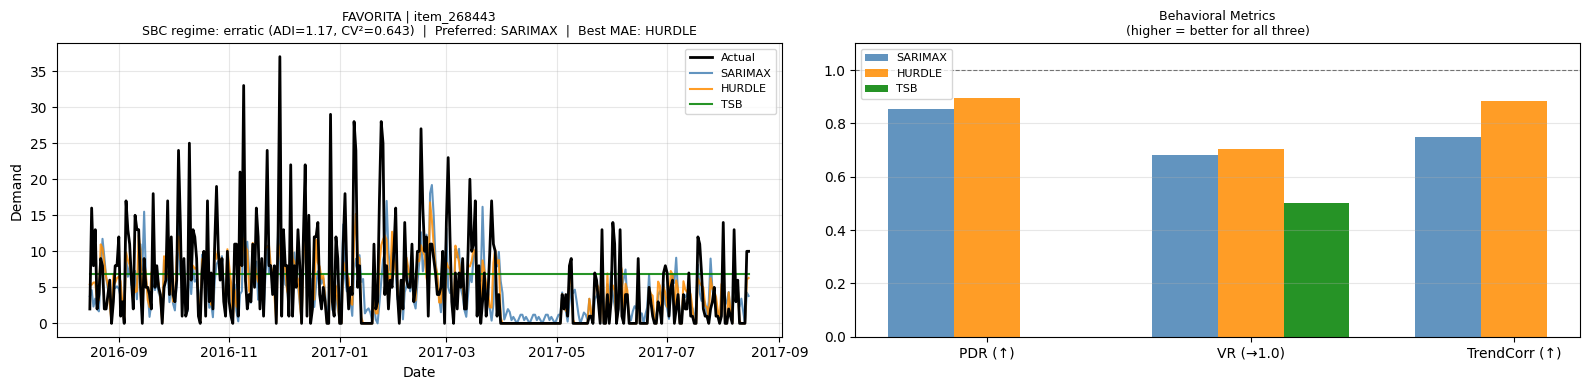

  model      mae     rmse      pdr           vr  trendcorr
 HURDLE 2.928161 4.807279 0.895833 5.797138e-01   0.885563
SARIMAX 3.672320 5.491167 0.854167 5.353967e-01   0.747495
    TSB 5.384960 6.615152 0.000000 1.363236e-16        NaN



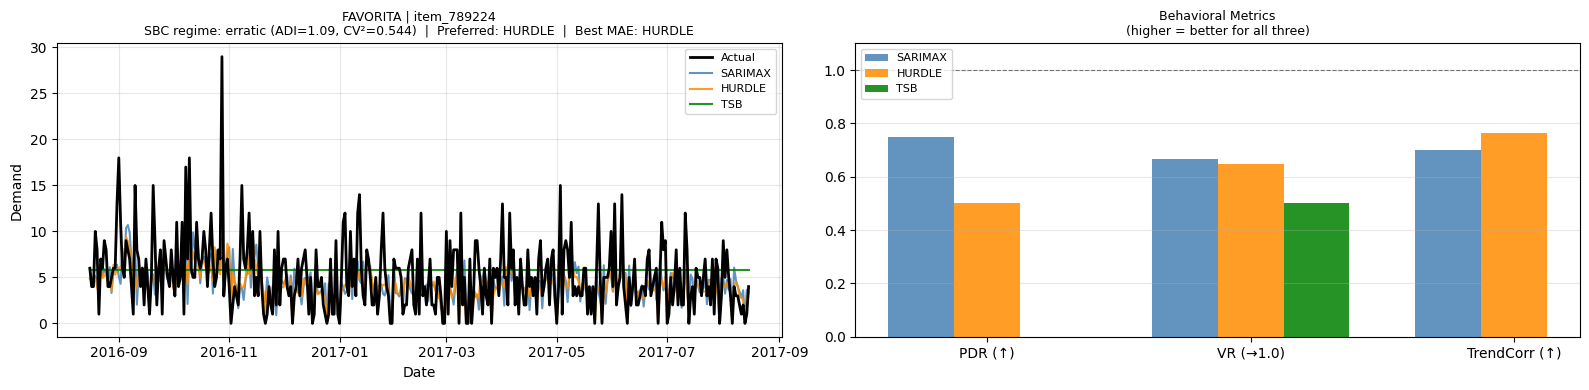

  model      mae     rmse  pdr           vr  trendcorr
 HURDLE 2.238927 3.228700 0.50 4.564898e-01   0.764977
SARIMAX 2.356789 3.238221 0.75 4.979310e-01   0.700234
    TSB 2.921688 3.761511 0.00 4.781252e-16        NaN



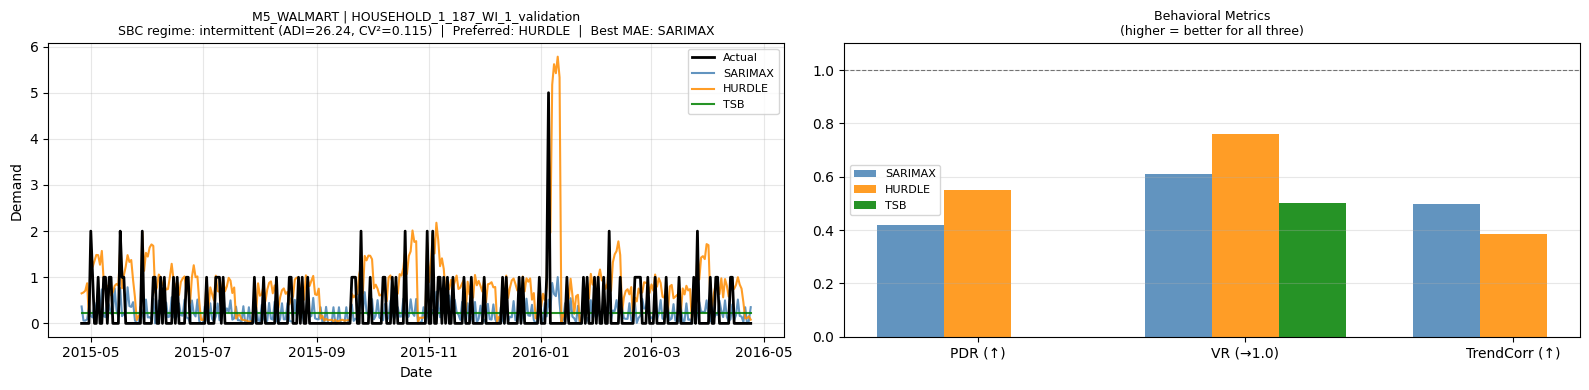

  model      mae     rmse      pdr           vr  trendcorr
SARIMAX 0.372296 0.556140 0.419355 3.620968e-01   0.498744
    TSB 0.384397 0.545763 0.000000 5.096061e-17        NaN
 HURDLE 0.679362 0.988851 0.548387 1.318040e+00   0.385042



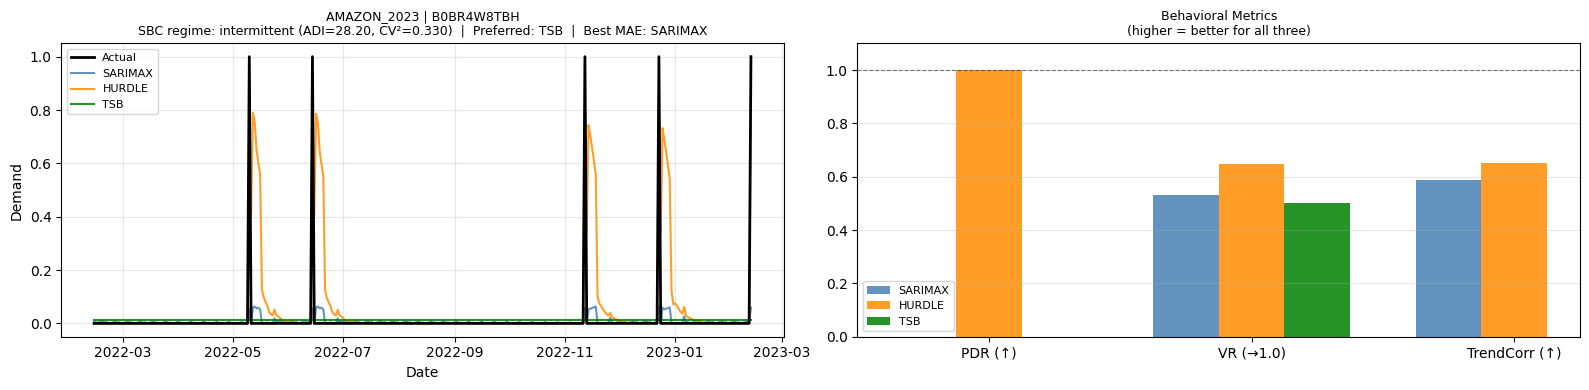

  model      mae     rmse  pdr       vr  trendcorr
SARIMAX 0.018746 0.111186  0.0 0.122659   0.588926
    TSB 0.025664 0.116245  0.0 0.000000        NaN
 HURDLE 0.049384 0.162524  1.0 1.545617   0.649865



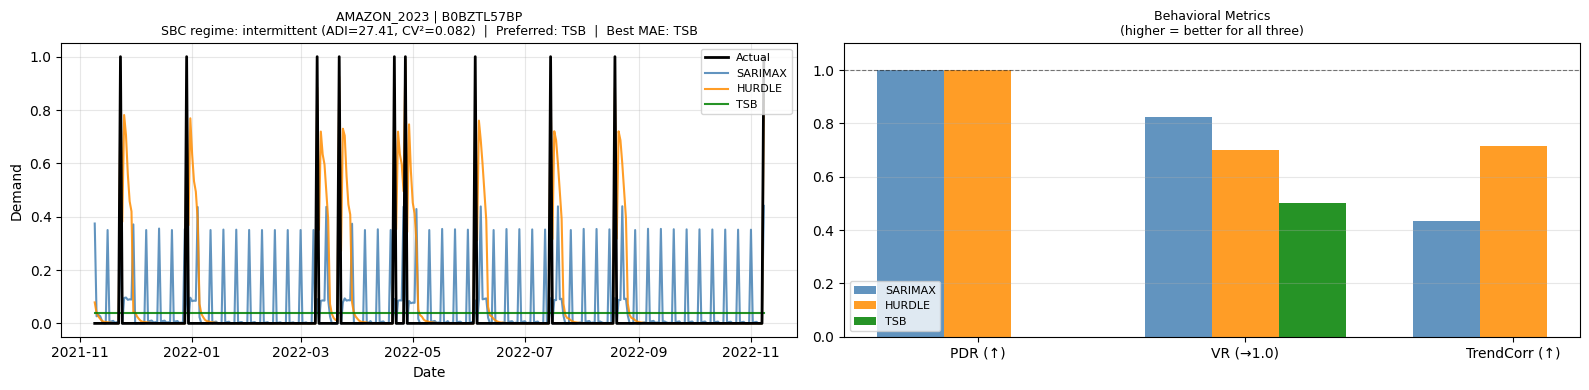

  model      mae     rmse  pdr           vr  trendcorr
    TSB 0.062843 0.163550  0.0 4.250783e-17        NaN
SARIMAX 0.083149 0.192884  1.0 7.864332e-01   0.433474
 HURDLE 0.084266 0.210914  1.0 1.431515e+00   0.716488



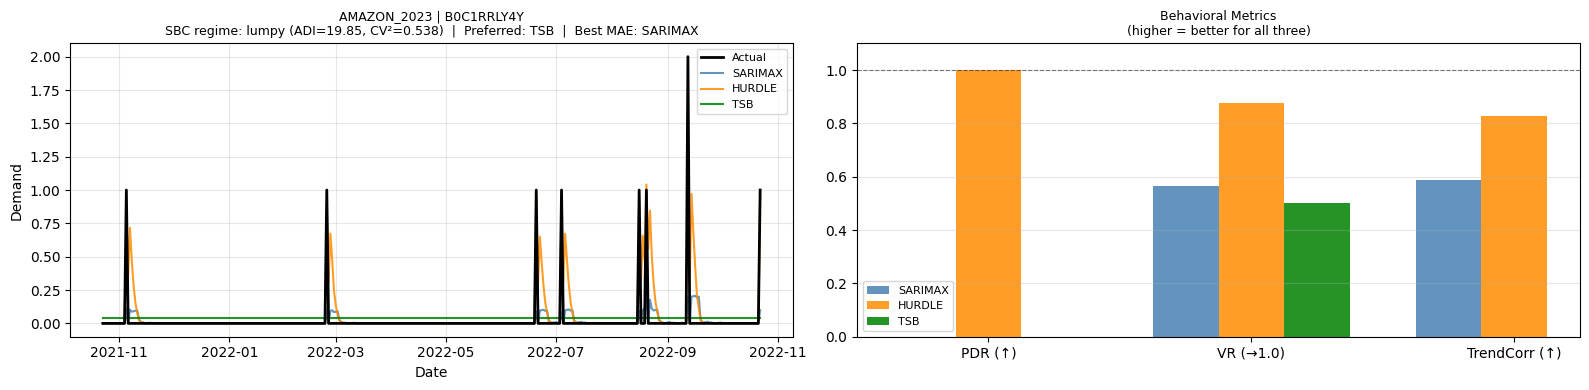

  model      mae     rmse  pdr       vr  trendcorr
SARIMAX 0.033249 0.159719  0.0 0.225007   0.588557
 HURDLE 0.043747 0.147257  1.0 1.141816   0.826917
    TSB 0.066697 0.172921  0.0 0.000000        NaN



In [11]:
colors = {'SARIMAX': 'steelblue', 'HURDLE': 'darkorange', 'TSB': 'green'}

for case in paper_cases:
    key = (case['dataset'], case['series_id'])
    if key not in per_case_outputs:
        continue

    out        = per_case_outputs[key]
    test_df    = out['test_df']
    metrics_df = out['metrics']
    sbc        = out['sbc']
    best_model = metrics_df.iloc[0]['model']

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # ── Left: full forecast comparison ──────────────────────────────────────
    ax = axes[0]
    ax.plot(test_df['date'], test_df['sales'].values,
            label='Actual', color='black', linewidth=2, zorder=5)
    for model_name, y_pred in out['predictions'].items():
        ax.plot(test_df['date'], y_pred,
                label=model_name, color=colors.get(model_name, 'gray'),
                alpha=0.85, linewidth=1.5)

    ax.set_title(
        f"{case['dataset']} | {case['series_id']}\n"
        f"SBC regime: {sbc['regime']} (ADI={sbc['adi']:.2f}, CV²={sbc['cv2']:.3f})  |  "
        f"Preferred: {case['preferred_model']}  |  Best MAE: {best_model}",
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.set_xlabel('Date')
    ax.set_ylabel('Demand')
    ax.grid(alpha=0.3)

    # ── Right: behavioral metrics bar chart ─────────────────────────────────
    ax2 = axes[1]
    beh_cols = ['pdr', 'vr', 'trendcorr']
    beh_labels = ['PDR (↑)', 'VR (→1.0)', 'TrendCorr (↑)']
    sub = metrics_df.set_index('model')[beh_cols]

    # Normalise VR closeness to 1.0 → convert to [0,1] where 1=perfect
    sub_plot = sub.copy()
    sub_plot['vr'] = 1 / (1 + np.abs(sub_plot['vr'] - 1.0))  # 1/(1+|VR-1|)

    x = np.arange(len(beh_labels))
    width = 0.25
    models_ordered = ['SARIMAX', 'HURDLE', 'TSB']
    for i, m in enumerate(models_ordered):
        if m not in sub_plot.index:
            continue
        vals = [sub_plot.loc[m, c] for c in beh_cols]
        ax2.bar(x + i * width, vals, width, label=m,
                color=colors.get(m, 'gray'), alpha=0.85)

    ax2.set_xticks(x + width)
    ax2.set_xticklabels(beh_labels)
    ax2.set_ylim(0, 1.1)
    ax2.set_title("Behavioral Metrics\n(higher = better for all three)", fontsize=9)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis='y')
    ax2.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Print metric table
    print(metrics_df[['model','mae','rmse','pdr','vr','trendcorr']].to_string(index=False))
    print()


## Where TSB Wins


In [12]:
# ── Where does TSB win? ───────────────────────────────────────────────────────
# This cell summarises model wins by regime and metric, which is the
# core empirical contribution for the paper.

print("MODEL WINS BY REGIME AND METRIC")
print("=" * 70)
print("Expected mapping:")
print("  smooth      regime → SARIMAX wins on MAE and PDR")
print("  erratic     regime → HURDLE wins on MAE and VR")
print("  intermittent regime → TSB wins on PDR and VR (lower safety stock)")
print("  lumpy       regime → HURDLE wins on MAE, TSB competitive on VR")
print()

win_rows = []
for case in paper_cases:
    ds  = case['dataset']
    sid = case['series_id']
    key = (ds, sid)
    if key not in per_case_outputs:
        continue

    out = per_case_outputs[key]
    mdf = out['metrics'].set_index('model')

    best_mae = mdf['mae'].idxmin()
    best_pdr = mdf['pdr'].dropna().idxmax() if not mdf['pdr'].dropna().empty else 'N/A'
    best_vr  = mdf['vr'].dropna().apply(lambda x: abs(x - 1.0)).idxmin()                if not mdf['vr'].dropna().empty else 'N/A'

    win_rows.append({
        'Series':      sid[-20:],
        'SBC regime':  out['sbc']['regime'],
        'Preferred':   case['preferred_model'],
        'Best MAE':    best_mae,
        'Best PDR':    best_pdr,
        'Best VR→1':   best_vr,
        'Correct?':    '✓' if best_mae == case['preferred_model'] or
                               best_pdr == case['preferred_model'] else '~',
    })

display(pd.DataFrame(win_rows))


MODEL WINS BY REGIME AND METRIC
Expected mapping:
  smooth      regime → SARIMAX wins on MAE and PDR
  erratic     regime → HURDLE wins on MAE and VR
  intermittent regime → TSB wins on PDR and VR (lower safety stock)
  lumpy       regime → HURDLE wins on MAE, TSB competitive on VR



,Series,SBC regime,Preferred,Best MAE,Best PDR,Best VR→1,Correct?
0,item_268443,erratic,SARIMAX,HURDLE,HURDLE,HURDLE,~
1,item_789224,erratic,HURDLE,HURDLE,SARIMAX,SARIMAX,✓
2,_187_WI_1_validation,intermittent,HURDLE,SARIMAX,HURDLE,HURDLE,✓
3,B0BR4W8TBH,intermittent,TSB,SARIMAX,HURDLE,HURDLE,~
4,B0BZTL57BP,intermittent,TSB,TSB,SARIMAX,SARIMAX,✓
5,B0C1RRLY4Y,lumpy,TSB,SARIMAX,HURDLE,HURDLE,~


## Paper-Ready Product Summary


In [13]:
product_summary = (
    results_df[
        ['dataset', 'series_id', 'semantic_product', 'expected_regime', 'preferred_model', 'mean_demand', 'std_demand', 'zero_rate', 'ADI', 'CV2']
    ]
    .drop_duplicates()
    .sort_values(['dataset', 'series_id'])
    .reset_index(drop=True)
)
product_summary


,dataset,series_id,semantic_product,expected_regime,preferred_model,mean_demand,std_demand,zero_rate,ADI,CV2
0,AMAZON_2023,B0BR4W8TBH,Personal care — sparse intermittent (TSB domain),intermittent,TSB,0.044139,0.266710,0.964544,28.204082,0.330019
1,AMAZON_2023,B0BZTL57BP,Household hygiene — sparse intermittent (TSB d...,intermittent,TSB,0.039261,0.210205,0.963510,27.405063,0.082491
2,AMAZON_2023,B0C1RRLY4Y,Household hygiene — weekly intermittent (TSB d...,intermittent,TSB,0.066331,0.360473,0.949622,19.850000,0.538215
3,FAVORITA,item_268443,"Cleaning product — high demand, stable regime",stable,SARIMAX,8.562027,8.251503,0.148260,1.174067,0.642819
4,FAVORITA,item_789224,Cleaning product — transition / variable regime,erratic,HURDLE,6.988654,5.792741,0.084720,1.092562,0.544113
5,M5_WALMART,HOUSEHOLD_1_187_WI_1_validation,Household retail — lumpy / transition regime,lumpy,HURDLE,0.046512,0.247273,0.961886,26.237288,0.115355


## Save Tables (Optional)


In [14]:
out_dir = REPO_ROOT / 'reports' / 'paper_experiments'
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / '25_single_category_model_results.csv'
summary_path = out_dir / '25_single_category_product_summary.csv'

results_df.to_csv(results_path, index=False)
product_summary.to_csv(summary_path, index=False)

print('Saved:', results_path)
print('Saved:', summary_path)


Saved: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\25_single_category_model_results.csv
Saved: C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\paper_experiments\25_single_category_product_summary.csv
